In [112]:
from sklearn.datasets import fetch_openml

In [113]:
data = fetch_openml("Brainsize")


In [114]:
data.DESCR

'**Author**:   \n**Source**: Unknown - Date unknown  \n**Please cite**:   \n\nDatasets of Data And Story Library, project illustrating use of basic statistic methods, converted to arff format by Hakan Kjellerstrand.\nSource: TunedIT: http://tunedit.org/repo/DASL\n\nDASL file http://lib.stat.cmu.edu/DASL/Datafiles/Brainsize.html\n\nBrain Size and Intelligence\n\nReference:   Willerman, L., Schultz, R., Rutledge, J. N., and Bigler, E. (1991), "In Vivo  Brain Size and Intelligence," Intelligence, 15, 223-228.\n\nAuthorization:   Contact authors\nDescription:   Willerman et al. (1991) collected a sample of  40 right-handed Anglo introductory psychology students at a large southwestern university. Subjects took  four subtests (Vocabulary, Similarities, Block Design, and Picture Completion) of the Wechsler (1981) Adult Intelligence Scale-Revised.   The researchers used Magnetic Resonance Imaging (MRI) to determine the brain size of the subjects.  Information about gender and body size (heigh

Задача: Определение общего количества пикселей по 18 МРТ-сканам.
Задача МЛ: Линейная регрессия для определения числа (количества пикселей по 18 МРТ-сканам)

In [116]:

X=data.data
X.head()

,Gender,FSIQ,VIQ,PIQ,Weight,Height
0,Female,133,132,124,118.0,64.5
1,Male,140,150,124,NaN,72.5
2,Male,139,123,150,143.0,73.3
3,Male,133,129,128,172.0,68.8
4,Female,137,132,134,147.0,65.0


In [117]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Gender  40 non-null     category
 1   FSIQ    40 non-null     int64   
 2   VIQ     40 non-null     int64   
 3   PIQ     40 non-null     int64   
 4   Weight  38 non-null     float64 
 5   Height  39 non-null     float64 
dtypes: category(1), float64(2), int64(3)
memory usage: 1.9 KB


Есть nan значение (пропуски)

In [118]:
X.describe()

,FSIQ,VIQ,PIQ,Weight,Height
count,40.000000,40.000000,40.00000,38.000000,39.000000
mean,113.450000,112.350000,111.02500,151.052632,68.525641
std,24.082071,23.616107,22.47105,23.478509,3.994649
min,77.000000,71.000000,72.00000,106.000000,62.000000
25%,89.750000,90.000000,88.25000,135.250000,66.000000
50%,116.500000,113.000000,115.00000,146.500000,68.000000
75%,135.500000,129.750000,128.00000,172.000000,70.500000
max,144.000000,150.000000,150.00000,192.000000,77.000000


Для преоброзавания данных в чиловой формат, категориальный прищнак преобразуем в числовой (male = 1, female = 0)

In [119]:
import numpy as np
X['Gender'] = np.where(X['Gender'] == 'Male', 1, 0)

X.head()

C:\Users\241990\AppData\Local\Temp\ipykernel_6964\3319042415.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Gender'] = np.where(X['Gender'] == 'Male', 1, 0)


,Gender,FSIQ,VIQ,PIQ,Weight,Height
0,0,133,132,124,118.0,64.5
1,1,140,150,124,NaN,72.5
2,1,139,123,150,143.0,73.3
3,1,133,129,128,172.0,68.8
4,0,137,132,134,147.0,65.0


In [120]:
y = data.target
y.head()

0     816932
1    1001121
2    1038437
3     965353
4     951545
Name: MRI_Count, dtype: int64

In [121]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 40 entries, 0 to 39
Series name: MRI_Count
Non-Null Count  Dtype
--------------  -----
40 non-null     int64
dtypes: int64(1)
memory usage: 452.0 bytes


Очистка данных от нулевых значений по маске

In [126]:
mask = X.notna().all(axis=1)

In [125]:
y = y[mask]
y.info()

<class 'pandas.core.series.Series'>
Index: 38 entries, 0 to 39
Series name: MRI_Count
Non-Null Count  Dtype
--------------  -----
38 non-null     int64
dtypes: int64(1)
memory usage: 608.0 bytes


In [127]:
X = X[mask]

In [128]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 39
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  38 non-null     int32  
 1   FSIQ    38 non-null     int64  
 2   VIQ     38 non-null     int64  
 3   PIQ     38 non-null     int64  
 4   Weight  38 non-null     float64
 5   Height  38 non-null     float64
dtypes: float64(2), int32(1), int64(3)
memory usage: 1.9 KB


Эмпирическое распределение для оценки дисбаланса

In [130]:
import matplotlib.pyplot as plt

(array([5., 3., 6., 6., 3., 9., 2., 1., 1., 2.]),
 array([ 790619.,  819512.,  848405.,  877298.,  906191.,  935084.,
         963977.,  992870., 1021763., 1050656., 1079549.]),
 <BarContainer object of 10 artists>)

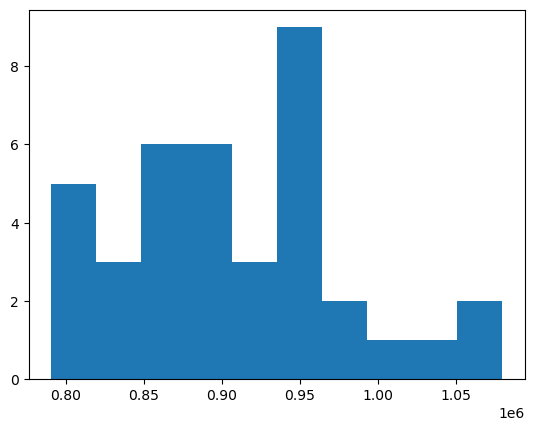

In [131]:
plt.hist(y)

Дисбаланс присутсвует

In [132]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import f1_score


Разделение данных на train и test

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=42)

In [141]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 17 to 30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  26 non-null     int32  
 1   FSIQ    26 non-null     int64  
 2   VIQ     26 non-null     int64  
 3   PIQ     26 non-null     int64  
 4   Weight  26 non-null     float64
 5   Height  26 non-null     float64
dtypes: float64(2), int32(1), int64(3)
memory usage: 1.3 KB


In [147]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Test score (r2):", model.score(X_test, y_test)) 

Test score (r2): 0.7251339838257683


In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

In [159]:
y_pred = model.predict(X_test)

# 3 дополнительных метрики:

In [160]:
mean_absolute_error(y_test, y_pred)

26040.152985089837

In [161]:
mean_squared_error(y_test, y_pred)

1140203859.8439043

In [162]:
median_absolute_error(y_test, y_pred)

13473.330202919431

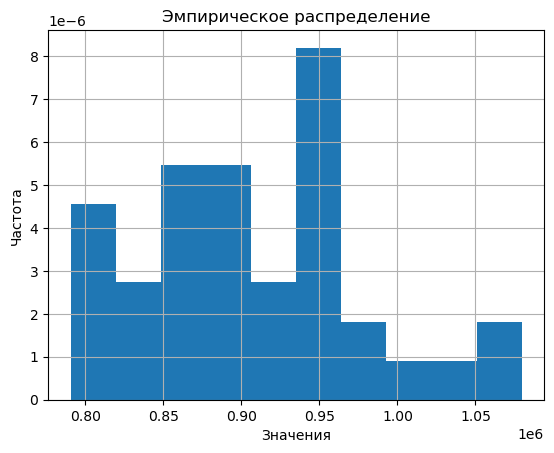

In [163]:
y.hist(bins=10, density=True)
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.title('Эмпирическое распределение')
plt.show()

In [178]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

In [185]:
X_train_norm, X_test_norm = pd.DataFrame(MinMaxScaler().fit_transform(X_train), columns=X.columns), pd.DataFrame(MinMaxScaler().fit_transform(X_test), columns=X.columns)

In [189]:
X_train_norm.head()

,Gender,FSIQ,VIQ,PIQ,Weight,Height
0,1.0,0.312500,0.316456,0.304348,0.831169,0.766667
1,0.0,0.937500,0.620253,0.956522,0.532468,0.566667
2,1.0,0.265625,0.455696,0.043478,0.935065,0.966667
3,0.0,0.812500,0.734177,0.623188,0.051948,0.166667
4,0.0,0.046875,0.240506,0.000000,0.376623,0.300000


In [198]:
model_norm = LinearRegression()
model_norm.fit(X_train_norm, y_train)

LinearRegression()

In [200]:
print("Test score (r2):", model_norm.score(X_test_norm, y_test)) 

Test score (r2): 0.41028723125018063


Тк r2 уменьшился то модуель стала хуже

In [205]:
y_pred = model_norm.predict(X_test)

In [206]:
mean_absolute_error(y_test, y_pred)

42235.66117482723

In [207]:
mean_squared_error(y_test, y_pred)

2446256487.020805

In [208]:
median_absolute_error(y_test, y_pred)

39715.47700097493

Судя по остальным метрикам модель стала хуже

In [191]:
from sklearn.model_selection import learning_curve

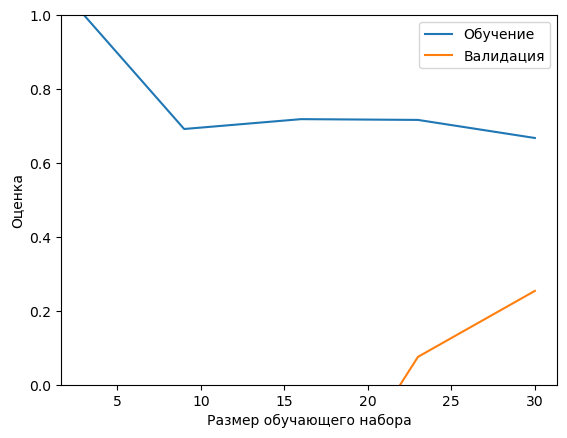

In [197]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

estimator = LinearRegression()
train_sizes, train_scores, test_scores = learning_curve(
    estimator, X, y, cv=5
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label='Обучение')
plt.plot(train_sizes, test_scores_mean, label='Валидация')
plt.xlabel('Размер обучающего набора')
plt.ylabel('Оценка')
plt.ylim(0, 1)
plt.legend()
plt.show()